<a href="https://colab.research.google.com/github/zaibshahzadi/DL-Internship/blob/main/Deeplearning_Iris_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Libraries + Data Load**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("Iris.csv")
df = df.drop(columns=["Id"])   # Id column feature nahi hai, hata dete hain
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


**Features (X) and Label (y)**

In [ ]:
X = df.iloc[:, 0:4].values.astype(float)   # 4 numeric features

# Binary label: Setosa = 1, baaki = 0
y = np.where(df["Species"].values == "Iris-setosa", 1, 0).reshape(-1, 1)

print(X.shape, y.shape)

(150, 4) (150, 1)


**Train/Test Split + Standardization**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization: mean=0, std=1 banate hain taake training fast ho
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Neural net ke conventions ke mutabiq transpose kar rahay hain -> (features, samples)
X_train_T = X_train.T
X_test_T = X_test.T
y_train_T = y_train.T
y_test_T = y_test.T

**Parameters Initialize**

In [ ]:
np.random.seed(42)

n_x = X_train_T.shape[0]   # input features = 4
n_h = 8                    # hidden neurons (aap change kar sakte hain)
n_y = 1                    # output neuron (binary)

W1 = np.random.randn(n_h, n_x) * 0.01
b1 = np.zeros((n_h, 1))
W2 = np.random.randn(n_y, n_h) * 0.01
b2 = np.zeros((n_y, 1))

**Activation Functions**

In [ ]:
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

**Forward Propagation**

In [ ]:
def forward_propagation(X, W1, b1, W2, b2):
    Z1 = W1 @ X + b1
    A1 = relu(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)
    cache = (Z1, A1, Z2, A2)
    return A2, cache

**Cost Function (Binary Cross-Entropy)**

In [ ]:
def compute_cost(A2, Y):
    m = Y.shape[1]
    eps = 1e-8   # log(0) se bachne ke liye
    cost = -np.sum(Y * np.log(A2 + eps) + (1 - Y) * np.log(1 - A2 + eps)) / m
    return float(np.squeeze(cost))

**Backward Propagation (Gradients)**

In [ ]:
def backward_propagation(X, Y, cache, W2):
    m = X.shape[1]
    Z1, A1, Z2, A2 = cache

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    dA1 = W2.T @ dZ2
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return dW1, db1, dW2, db2

**Parameters Update + Accuracy Function**

In [ ]:
def update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, lr):
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2
    return W1, b1, W2, b2

def accuracy(A2, Y):
    predictions = (A2 > 0.5).astype(int)
    return float(np.mean(predictions == Y))

**Training Loop**

In [ ]:
learning_rate = 0.5
epochs = 2000

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    A2_train, cache = forward_propagation(X_train_T, W1, b1, W2, b2)
    cost = compute_cost(A2_train, y_train_T)
    dW1, db1, dW2, db2 = backward_propagation(X_train_T, y_train_T, cache, W2)
    W1, b1, W2, b2 = update_parameters(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate)

    A2_test, _ = forward_propagation(X_test_T, W1, b1, W2, b2)
    test_cost = compute_cost(A2_test, y_test_T)

    train_losses.append(cost)
    test_losses.append(test_cost)
    train_accs.append(accuracy(A2_train, y_train_T))
    test_accs.append(accuracy(A2_test, y_test_T))

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Train Loss: {cost:.4f} | Test Loss: {test_cost:.4f} "
              f"| Train Acc: {train_accs[-1]:.3f} | Test Acc: {test_accs[-1]:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch    0 | Train Loss: 0.6931 | Test Loss: 0.6799 | Train Acc: 0.725 | Test Acc: 0.667
Epoch  200 | Train Loss: 0.0018 | Test Loss: 0.0051 | Train Acc: 1.000 | Test Acc: 1.000
Epoch  400 | Train Loss: 0.0007 | Test Loss: 0.0043 | Train Acc: 1.000 | Test Acc: 1.000
Epoch  600 | Train Loss: 0.0004 | Test Loss: 0.0041 | Train Acc: 1.000 | Test Acc: 1.000
Epoch  800 | Train Loss: 0.0003 | Test Loss: 0.0040 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 1000 | Train Loss: 0.0002 | Test Loss: 0.0040 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 1200 | Train Loss: 0.0002 | Test Loss: 0.0039 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 1400 | Train Loss: 0.0002 | Test Loss: 0.0039 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 1600 | Train Loss: 0.0001 | Test Loss: 0.0039 | Train Acc: 1.000 | Test Acc: 1.000
Epoch 1800 | Train Loss: 0.0001 | Test Loss: 0.0038 | Train Acc: 1.000 | Test Acc: 1.000

Final Test Accuracy: 100.00%


**Loss & Accuracy Curves Plot**

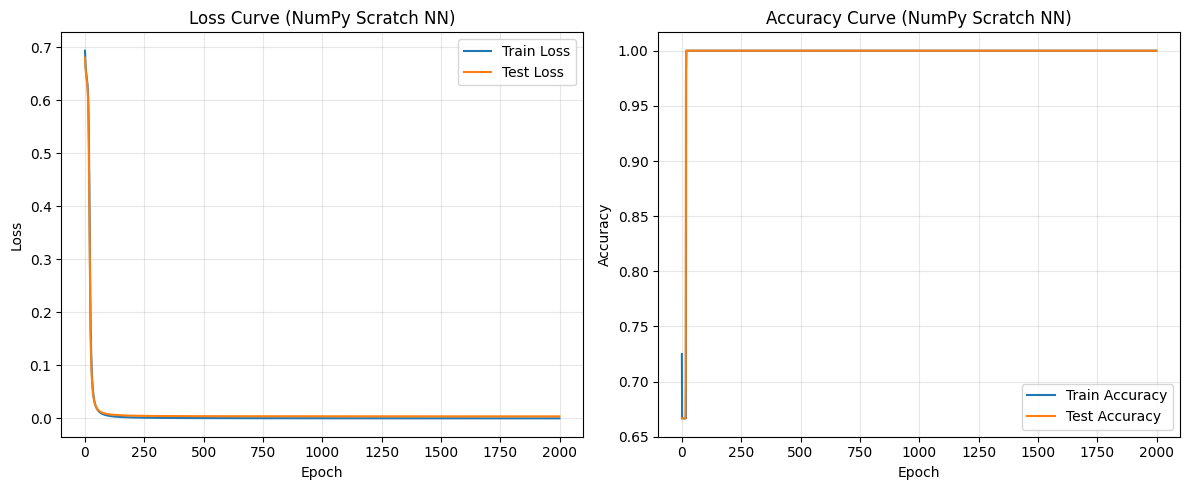

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (NumPy Scratch NN)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (NumPy Scratch NN)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Confusion Matrix + Precision, Recall, F1**

Confusion Matrix:
[[20  0]
 [ 0 10]]

Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000

Classification Report:
              precision    recall  f1-score   support

  Not-Setosa       1.00      1.00      1.00        20
      Setosa       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



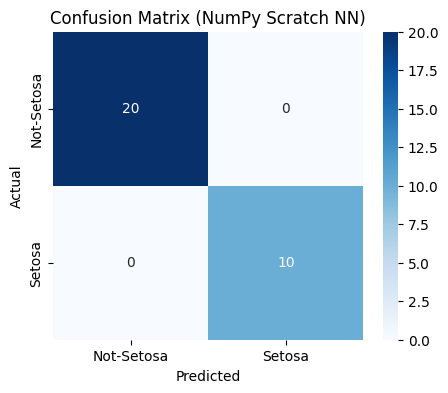

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

# Final predictions test set par
final_preds = (A2_test > 0.5).astype(int).flatten()
final_actual = y_test_T.flatten()

# Confusion Matrix
cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

# Precision, Recall, F1
precision = precision_score(final_actual, final_preds)
recall = recall_score(final_actual, final_preds)
f1 = f1_score(final_actual, final_preds)

print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Detailed report
print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=["Not-Setosa", "Setosa"]))

# Confusion Matrix Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not-Setosa", "Setosa"],
            yticklabels=["Not-Setosa", "Setosa"])
plt.title("Confusion Matrix (NumPy Scratch NN)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**Re-implementation using PyTorch — Multi-class Classification**

**Install/Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

torch.manual_seed(42)
np.random.seed(42)

**Data Load + Preprocessing**

In [ ]:
df = pd.read_csv("Iris.csv")
df = df.drop(columns=["Id"])

X = df.iloc[:, 0:4].values.astype(np.float32)

le = LabelEncoder()
y = le.fit_transform(df["Species"].values)   # setosa=0, versicolor=1, virginica=2
print("Classes:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

Classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


**MLP Model**

In [ ]:
class IrisMLP(nn.Module):
    def __init__(self, in_features=4, hidden1=16, hidden2=8, out_classes=3, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),      # Dropout -> overfitting kam karta hai
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden2, out_classes)
        )

    def forward(self, x):
        return self.net(x)

model = IrisMLP()
print(model)

IrisMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=16, out_features=8, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=8, out_features=3, bias=True)
  )
)


**Loss Function + Optimizer (L2 Regularization)**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)

**Training Loop**

In [ ]:
epochs = 300
train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(epochs):
    model.train()   # dropout ON
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    train_preds = outputs.argmax(dim=1)
    train_acc = (train_preds == y_train_t).float().mean().item()

    model.eval()    # dropout OFF (testing ke waqt dropout use nahi hota)
    with torch.no_grad():
        test_outputs = model(X_test_t)
        test_loss = criterion(test_outputs, y_test_t)
        test_preds = test_outputs.argmax(dim=1)
        test_acc = (test_preds == y_test_t).float().mean().item()

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d} | Train Loss: {loss.item():.4f} | Test Loss: {test_loss.item():.4f} "
              f"| Train Acc: {train_acc:.3f} | Test Acc: {test_acc:.3f}")

print(f"\nFinal Test Accuracy: {test_accs[-1]*100:.2f}%")

Epoch   0 | Train Loss: 1.1007 | Test Loss: 1.0703 | Train Acc: 0.350 | Test Acc: 0.333
Epoch  30 | Train Loss: 0.3971 | Test Loss: 0.3292 | Train Acc: 0.850 | Test Acc: 0.800
Epoch  60 | Train Loss: 0.1893 | Test Loss: 0.1678 | Train Acc: 0.958 | Test Acc: 0.933
Epoch  90 | Train Loss: 0.1386 | Test Loss: 0.1149 | Train Acc: 0.967 | Test Acc: 0.967
Epoch 120 | Train Loss: 0.1618 | Test Loss: 0.1073 | Train Acc: 0.933 | Test Acc: 0.933
Epoch 150 | Train Loss: 0.1612 | Test Loss: 0.0843 | Train Acc: 0.933 | Test Acc: 0.967
Epoch 180 | Train Loss: 0.1329 | Test Loss: 0.0775 | Train Acc: 0.950 | Test Acc: 0.967
Epoch 210 | Train Loss: 0.0932 | Test Loss: 0.0758 | Train Acc: 0.958 | Test Acc: 0.967
Epoch 240 | Train Loss: 0.0919 | Test Loss: 0.0700 | Train Acc: 0.958 | Test Acc: 0.967
Epoch 270 | Train Loss: 0.0982 | Test Loss: 0.0686 | Train Acc: 0.967 | Test Acc: 0.967

Final Test Accuracy: 96.67%


**Loss & Accuracy Curves**

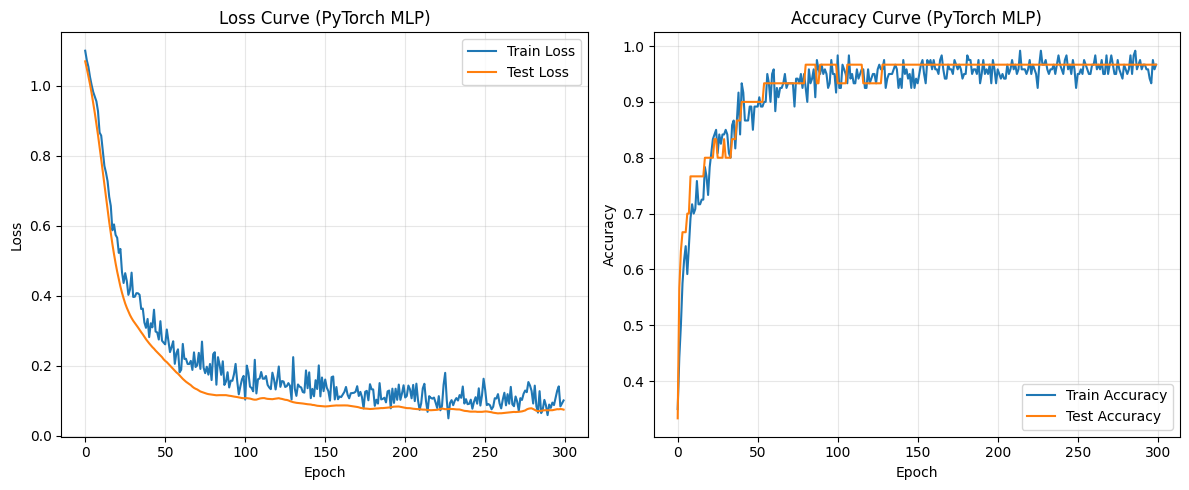

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses, label="Test Loss")
axes[0].set_title("Loss Curve (PyTorch MLP)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs, label="Test Accuracy")
axes[1].set_title("Accuracy Curve (PyTorch MLP)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Confusion Matrix + Precision, Recall, F1 (Multi-class)**

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Precision (macro): 0.9697
Recall (macro):    0.9667
F1-Score (macro):  0.9666

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



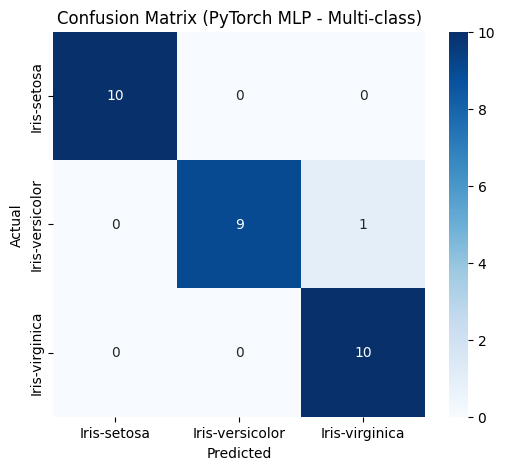

In [ ]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, classification_report
import seaborn as sns

model.eval()
with torch.no_grad():
    final_outputs = model(X_test_t)
    final_preds = final_outputs.argmax(dim=1).numpy()

final_actual = y_test_t.numpy()
class_names = list(le.classes_)   # ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

# Confusion Matrix
cm = confusion_matrix(final_actual, final_preds)
print("Confusion Matrix:")
print(cm)

# Precision, Recall, F1 (macro average -> teeno classes ka equal weight)
precision = precision_score(final_actual, final_preds, average="macro")
recall = recall_score(final_actual, final_preds, average="macro")
f1 = f1_score(final_actual, final_preds, average="macro")

print(f"\nPrecision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print(f"F1-Score (macro):  {f1:.4f}")

# Detailed per-class report
print("\nClassification Report:")
print(classification_report(final_actual, final_preds, target_names=class_names))

# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix (PyTorch MLP - Multi-class)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()